# Assessment | Statistical Evaluation Mini-Project

Work through the four tasks below using the **Auto MPG** dataset. Each task has its own section with scaffolding cells — add as many code and markdown cells as you need.

## Setup

Run the cell below to load the dataset and verify everything is working.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

SEED = 42
np.random.seed(SEED)

mpg = sns.load_dataset("mpg").dropna() 

print(f"Rows: {len(mpg)}, Columns: {mpg.shape[1]}") 
print(f"Origin groups: {mpg['origin'].unique().tolist()}") 
mpg.head() 

Rows: 392, Columns: 9
Origin groups: ['usa', 'japan', 'europe']


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [3]:
mpg.describe() 

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,23.445918,5.471939,194.411990,104.469388,2977.584184,15.541327,75.979592
std,7.805007,1.705783,104.644004,38.491160,849.402560,2.758864,3.683737
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.000000,4.000000,105.000000,75.000000,2225.250000,13.775000,73.000000
50%,22.750000,4.000000,151.000000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,275.750000,126.000000,3614.750000,17.025000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


---
## Task 1 — Correlation Analysis

1. Choose at least three pairs of numeric variables and compute Pearson and Spearman correlations.
2. Test each for significance (report p-values).
3. Create a correlation heatmap and at least two scatter plots with regression lines.
4. Explain when Pearson vs. Spearman is more appropriate, using your results as examples.

In [4]:
# all numeric and categorical values; 

# numeric values; 
# mpg 
# displacement 
# horsepower 
# weight 
# acceleration 

# categorical values;  
# origin 
# model_year 
# name 

In [5]:
# I chose those combinations; (weight, horsepower), (displacement, horsepower), (weight, acceleration) 

In [6]:
# Correlation coefficients and p-values

from scipy import stats

pairs = [
    ('weight', 'horsepower'),
    ('displacement', 'horsepower'),
    ('weight','acceleration')
]

for col1, col2 in pairs:
    print(f"{col1} vs {col2}")

    r_p, p_p = stats.pearsonr(mpg[col1], mpg[col2])
    print(f"Pearson r: {r_p:.4f}, p_vavlue: {p_p:.6f}")

    r_s, p_s = stats.spearmanr(mpg[col1], mpg[col2])
    print(f"Spearman r: {r_s:.4f}, p_vavlue: {p_s:.6f}") 

weight vs horsepower
Pearson r: 0.8645, p_vavlue: 0.000000
Spearman r: 0.8788, p_vavlue: 0.000000
displacement vs horsepower
Pearson r: 0.8973, p_vavlue: 0.000000
Spearman r: 0.8762, p_vavlue: 0.000000
weight vs acceleration
Pearson r: -0.4168, p_vavlue: 0.000000
Spearman r: -0.4051, p_vavlue: 0.000000


In [7]:
# |r| < 0.1: Negligible
# 0.1 ≤ |r| < 0.3: Weak
# 0.3 ≤ |r| < 0.5: Moderate
# 0.5 ≤ |r| < 0.7: Strong
# |r| ≥ 0.7: Very strong 

# if i consider these rules from the lecture; 

# ('weight', 'horsepower') 

# Pearson r = 0.86 very strong,    (p < 0.05) Significant
# Spearman r = 0.88 very strong,   (p < 0.05) Significant

# ('displacement', 'horsepower') 

# Pearson r = 0.90 very strong,    (p < 0.05) Significant
# Spearman r = 0.88 very strong,   (p < 0.05) Significant

# ('weight','acceleration') 

# Pearson r = -0.4168 Moderate,    (p < 0.05) Significant
# Spearman r = -0.4051 Moderate,   (p < 0.05) Significant 

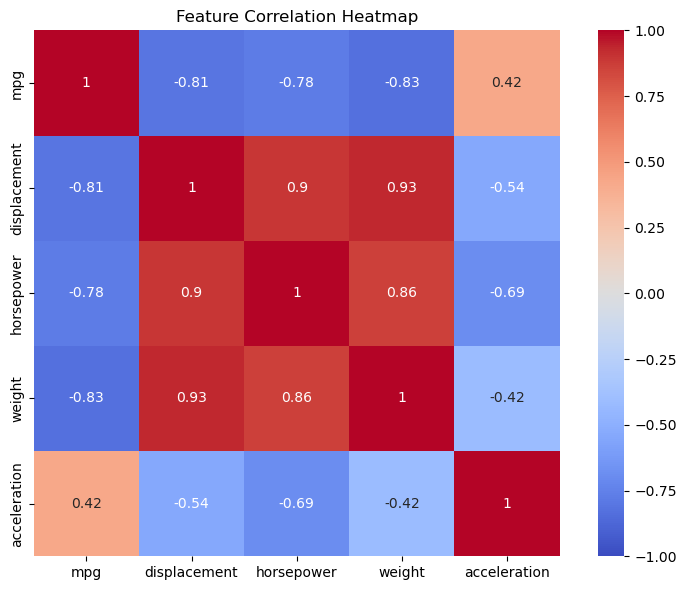

In [8]:
# Correlation heatmap

mpg_corr = mpg[['mpg', 'displacement', 'horsepower', 'weight', 'acceleration']]

corr_matrix = mpg_corr.corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            vmin=-1, vmax=1, square=True, ax=ax)
ax.set_title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show() 

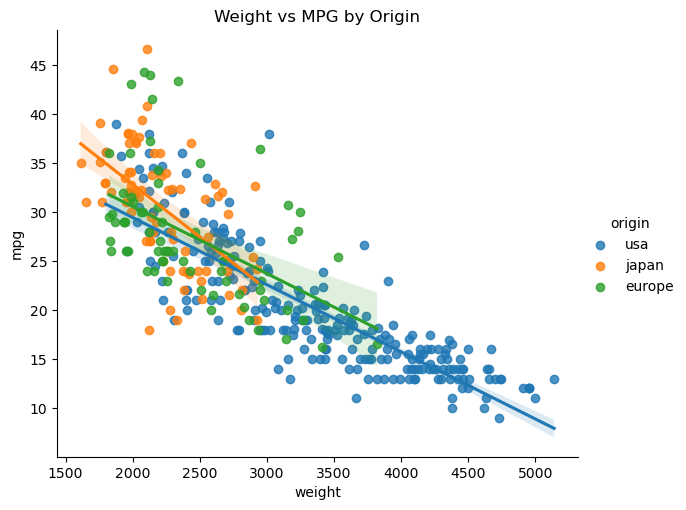

In [9]:
# Scatter plots with regression lines

sns.lmplot(data=mpg, x='weight', y='mpg', hue='origin', height=5, aspect=1.2)

plt.title('Weight vs MPG by Origin')
plt.show() 

In [10]:
# This is a little bit confusing, so you can see them below clearly one by one. 

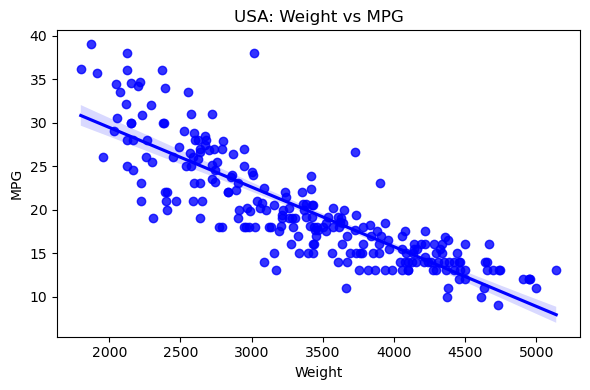

In [11]:
usa = mpg[mpg['origin'] == 'usa']

plt.figure(figsize=(6, 4))
sns.regplot(data=usa, x='weight', y='mpg', color = 'blue')

plt.title('USA: Weight vs MPG')
plt.xlabel('Weight')
plt.ylabel('MPG')
plt.tight_layout()
plt.show() 

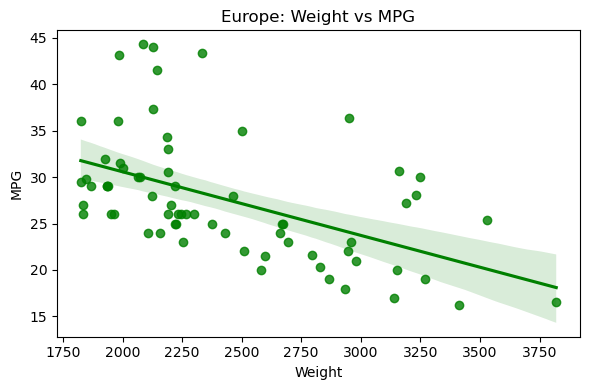

In [12]:
europe = mpg[mpg['origin'] == 'europe']

plt.figure(figsize=(6, 4))
sns.regplot(data=europe, x='weight', y='mpg', color = 'green')

plt.title('Europe: Weight vs MPG')
plt.xlabel('Weight')
plt.ylabel('MPG')
plt.tight_layout()
plt.show() 

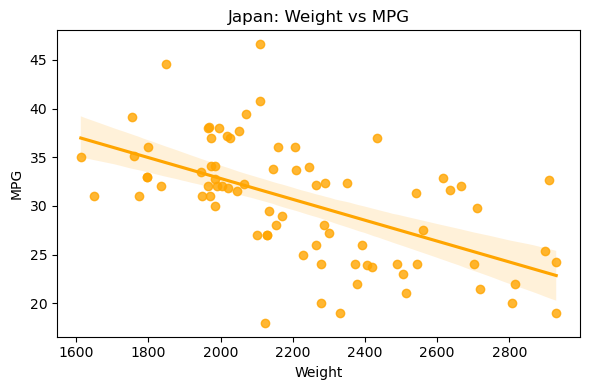

In [13]:
japan = mpg[mpg['origin'] == 'japan']

plt.figure(figsize=(6, 4))
sns.regplot(data=japan, x='weight', y='mpg', color = 'orange')

plt.title('Japan: Weight vs MPG')
plt.xlabel('Weight')
plt.ylabel('MPG')
plt.tight_layout()
plt.show()

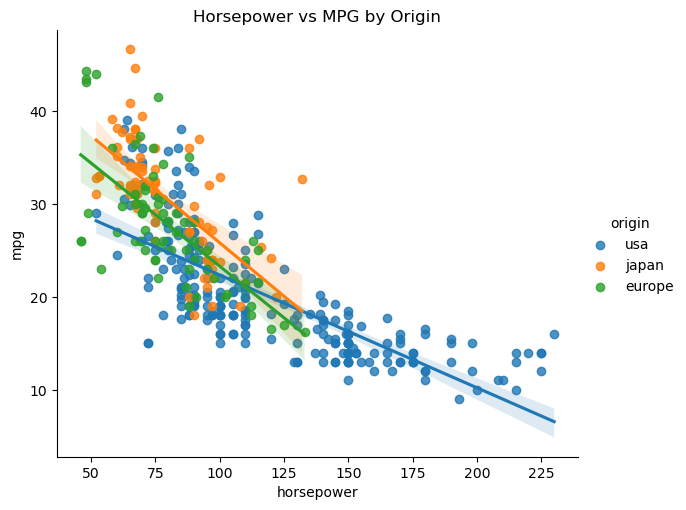

In [14]:
sns.lmplot(data=mpg, x='horsepower', y='mpg', hue='origin', height=5, aspect=1.2)

plt.title('Horsepower vs MPG by Origin')
plt.show() 

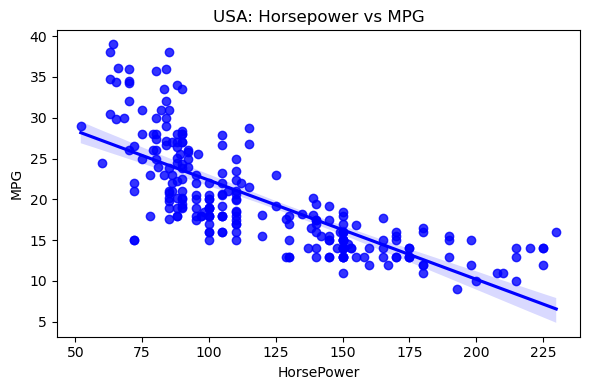

In [15]:
usa = mpg[mpg['origin'] == 'usa']

plt.figure(figsize=(6, 4))
sns.regplot(data=usa, x='horsepower', y='mpg', color = 'blue')

plt.title('USA: Horsepower vs MPG')
plt.xlabel('HorsePower')
plt.ylabel('MPG')
plt.tight_layout()
plt.show() 

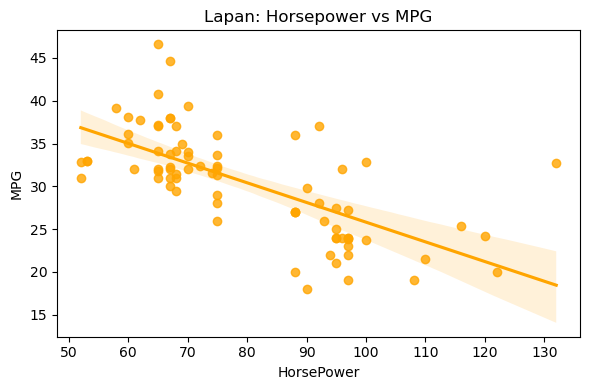

In [16]:
japan = mpg[mpg['origin'] == 'japan']

plt.figure(figsize=(6, 4))
sns.regplot(data=japan, x='horsepower', y='mpg', color = 'orange')

plt.title('Lapan: Horsepower vs MPG')
plt.xlabel('HorsePower')
plt.ylabel('MPG')
plt.tight_layout()
plt.show() 

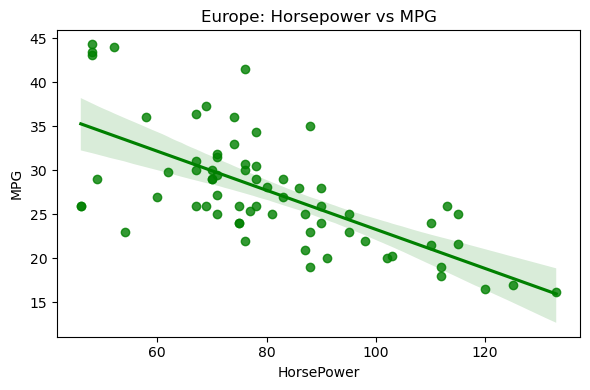

In [17]:
europe = mpg[mpg['origin'] == 'europe']

plt.figure(figsize=(6, 4))
sns.regplot(data=europe, x='horsepower', y='mpg', color = 'green')

plt.title('Europe: Horsepower vs MPG')
plt.xlabel('HorsePower')
plt.ylabel('MPG')
plt.tight_layout()
plt.show() 

### Interpretation

*When is Pearson vs. Spearman more appropriate? Use your results as examples.*

Your answer here…

#### weight vs horsepower
##### Pearson r = 0.86
##### Spearman r = 0.88
##### Pearson is appropriate because the relationship is approximately linear.

#### displacement vs horsepower
##### Pearson r = 0.90
##### Spearman r = 0.88
##### Pearson works well because the relationship is strongly linear and monotonic.

#### weight vs acceleration
##### Pearson r = -0.4168
##### Spearman r = -0.4051
##### Spearman is more reliable here because it focuses on rank order, not exact linear distance. 

---
## Task 2 — Group Comparisons

1. Choose a numeric variable and visualize its distribution by origin (box/violin plot).
2. Check ANOVA assumptions: Shapiro-Wilk (normality) and Levene's test (equal variances).
3. Run one-way ANOVA — report F-statistic, p-value, and eta-squared.
4. If significant, run Tukey's HSD and state which groups differ.

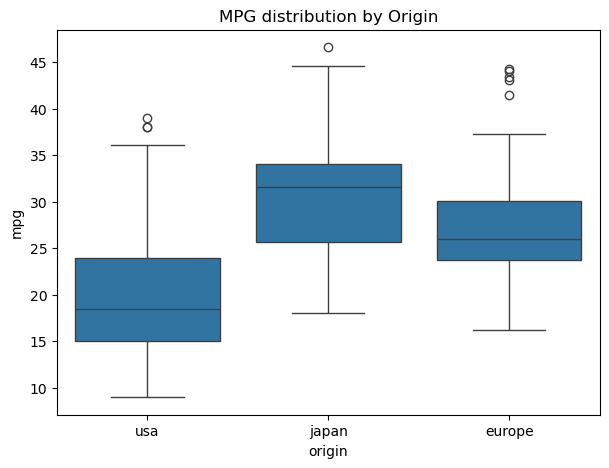

In [18]:
# Distribution visualization by origin

# Okay, I chose mpg as numerical variable. 

plt.figure(figsize=(7, 5))
sns.boxplot(data=mpg, x='origin', y='mpg')

plt.title('MPG distribution by Origin')
plt.show() 

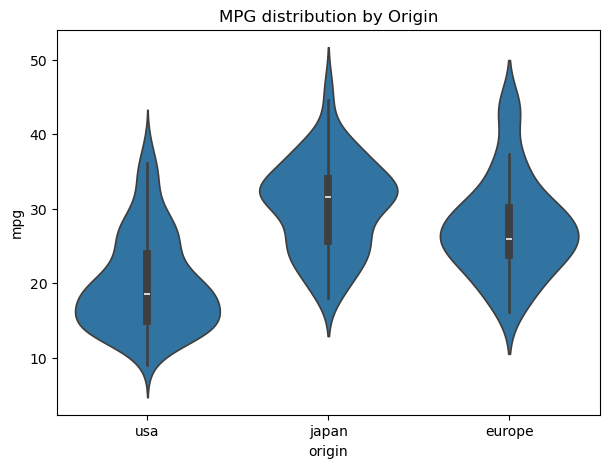

In [19]:
plt.figure(figsize=(7, 5))
sns.violinplot(data=mpg, x='origin', y='mpg')

plt.title('MPG distribution by Origin')
plt.show() 

In [20]:
# Assumption checks: Shapiro-Wilk + Levene's test

from scipy import stats

# Shapiro-Wilk
for origin in mpg['origin'].unique():
    group = mpg[mpg['origin'] == origin]['mpg']
    stat, p = stats.shapiro(group)
    print(f"{origin}: p-value = {p:.4f}")

# usa ; p = 0.0000, p < 0.05 not normal
# japan ; p = 0.2420, p > 0.05 normal
# europe ; p = 0.0054, p < 0.05 not normal 

# Levene's test
groups = [mpg[mpg['origin'] == o]['mpg'] for o in mpg['origin'].unique()]

stat, p = stats.levene(*groups)
print(f"Levene test p-value: {p:.4f}") 

# p = 0.9175, p > 0.05, equal variance 

usa: p-value = 0.0000
japan: p-value = 0.2420
europe: p-value = 0.0054
Levene test p-value: 0.9175


In [21]:
# One-way ANOVA

f_stat, p_value = stats.f_oneway(*groups)

print(f"F-statistic: {f_stat:.4f}")
print(f"p-value: {p_value:.6f}") 

ss_between = sum(len(g) * (g.mean() - mpg['mpg'].mean())**2 for g in groups)
ss_total = sum((mpg['mpg'] - mpg['mpg'].mean())**2)

eta_squared = ss_between / ss_total
print(f"Eta-squared: {eta_squared:.4f}")

# effect size = 0.3318 

# 0.01 → small effect
# 0.06 → medium
# 0.14+ → large effect

# So, our effect size is large 
# And p = 0.00000, so anova is significant

F-statistic: 96.6015
p-value: 0.000000
Eta-squared: 0.3318


In [22]:
# Post-hoc test (Tukey's HSD)

from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(
    endog=mpg['mpg'],
    groups=mpg['origin'],
    alpha=0.05
)

print(tukey) 

# Because in reject column all are true, it means all combinations(europe and japan, europe and usa, japan and usa) are significantly different. 

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
europe  japan   2.8477 0.0203   0.3583   5.337   True
europe    usa  -7.5695    0.0  -9.6321 -5.5068   True
 japan    usa -10.4172    0.0 -12.3642 -8.4701   True
-----------------------------------------------------


### Interpretation

*Which groups differ? What does the effect size tell you?*

Your answer here…

##### All groups are different from each other. Because we got true in reject column.
##### We calculate is there any difference with p value, and check the strongness of the difference with effect size, for example in my anova it was large. 

---
## Task 3 — Classification with Bootstrap Confidence Intervals

1. Prepare features (numeric columns) and target (`origin`). Train/test split (75/25, stratified).
2. Train at least two classifiers with default hyperparameters.
3. Print a classification report for each.
4. Write `bootstrap_metric()` and compute 95 % CIs for F1, precision, and recall.
5. Visualize the CIs and state which model you recommend.

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score

numeric_cols = ["mpg", "cylinders", "displacement", "horsepower",
                "weight", "acceleration", "model_year"]

X = mpg[numeric_cols].values
y = mpg["origin"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=SEED
)

print(f"Train: {len(X_train)}, Test: {len(X_test)}")
print(f"Class distribution (test): {pd.Series(y_test).value_counts().to_dict()}")

Train: 294, Test: 98
Class distribution (test): {'usa': 61, 'japan': 20, 'europe': 17}


In [29]:
# Train classifiers and generate predictions
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Models
log_reg = LogisticRegression(max_iter=1000)
rf = RandomForestClassifier(random_state=SEED)

# Train
log_reg.fit(X_train, y_train)
rf.fit(X_train, y_train) 

C:\Users\User\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [30]:
# Predictions
y_pred_lr = log_reg.predict(X_test)
y_pred_rf = rf.predict(X_test)

# Classification reports 
print("Logistic Regression:\n")
print(classification_report(y_test, y_pred_lr))

print("Random Forest:\n")
print(classification_report(y_test, y_pred_rf))

Logistic Regression:

              precision    recall  f1-score   support

      europe       0.67      0.47      0.55        17
       japan       0.59      0.65      0.62        20
         usa       0.89      0.93      0.91        61

    accuracy                           0.80        98
   macro avg       0.72      0.69      0.69        98
weighted avg       0.79      0.80      0.79        98

Random Forest:

              precision    recall  f1-score   support

      europe       0.80      0.71      0.75        17
       japan       0.76      0.65      0.70        20
         usa       0.89      0.97      0.93        61

    accuracy                           0.86        98
   macro avg       0.82      0.77      0.79        98
weighted avg       0.85      0.86      0.85        98



In [32]:
def bootstrap_metric(y_true, y_pred, metric_func, n_bootstrap=1000):
    """Compute bootstrap 95% confidence interval for a classification metric.

    Returns
    -------
    point_estimate : float
    ci_lower : float
    ci_upper : float
    boot_scores : np.ndarray
    """
    scores = []
    n = len(y_true)
    
    for _ in range(n_bootstrap):
        indices = np.random.choice(range(n), size=n, replace=True)
        score = metric_func(y_true[indices], y_pred[indices], average='weighted')
        scores.append(score)
    
    lower = np.percentile(scores, 2.5)
    upper = np.percentile(scores, 97.5)
    
    return np.mean(scores), lower, upper
    pass

In [33]:
# Apply bootstrap_metric for F1, precision, and recall (each model)
metrics = {
    "F1": f1_score,
    "Precision": precision_score,
    "Recall": recall_score
}

results = {}

for name, y_pred in {
    "LogReg": y_pred_lr,
    "RandomForest": y_pred_rf
}.items():
    
    results[name] = {}
    
    for metric_name, func in metrics.items():
        mean, low, high = bootstrap_metric(y_test, y_pred, func)
        results[name][metric_name] = (mean, low, high)

# Print results
for model, vals in results.items():
    print(f"\n{model}:")
    for metric, (mean, low, high) in vals.items():
        print(f"{metric}: {mean:.3f} (95% CI: {low:.3f}–{high:.3f})")


LogReg:
F1: 0.789 (95% CI: 0.700–0.874)
Precision: 0.795 (95% CI: 0.702–0.878)
Recall: 0.796 (95% CI: 0.714–0.878)

RandomForest:
F1: 0.852 (95% CI: 0.777–0.925)
Precision: 0.856 (95% CI: 0.771–0.923)
Recall: 0.856 (95% CI: 0.786–0.918)


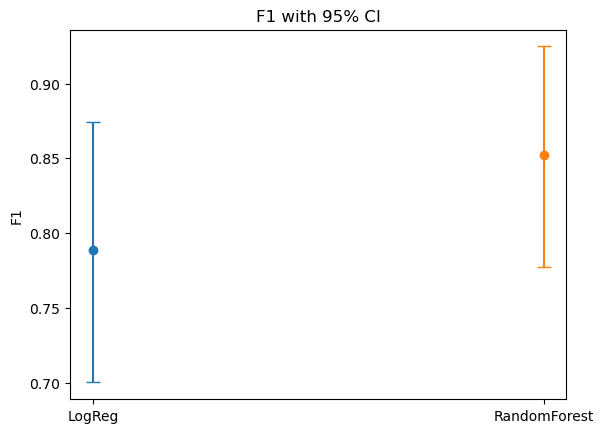

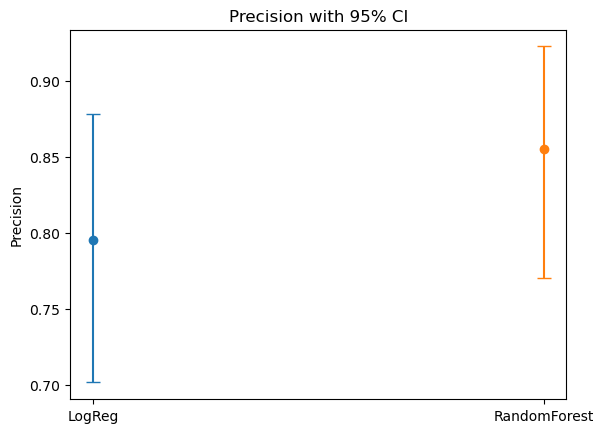

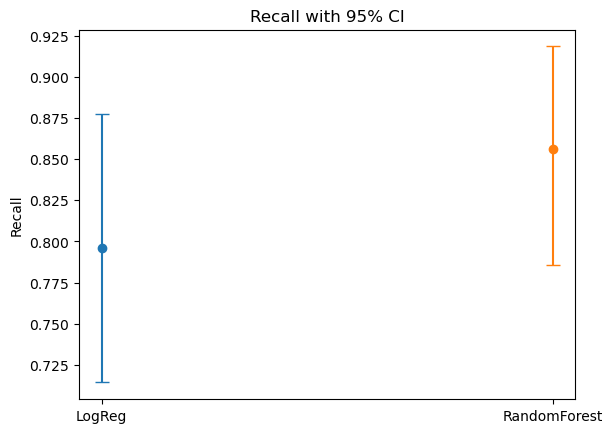

In [34]:
# Visualize bootstrap CIs (dot-and-whisker or grouped bar chart)
import matplotlib.pyplot as plt

for metric in metrics.keys():
    plt.figure()
    
    for model in results:
        mean, low, high = results[model][metric]
        plt.errorbar(model, mean, 
                     yerr=[[mean - low], [high - mean]], 
                     fmt='o', capsize=5)
    
    plt.title(f"{metric} with 95% CI")
    plt.ylabel(metric)
    plt.show()

### Recommendation

*Which model would you recommend? How confident are you based on the CIs?*

Your answer here…

#### I would strongly recommend RandomForest Classifier. Why? Well, i have 3 main reasons.

##### Higher F1-score → better model (RandomForest got higher F1 score)
##### In terms of Confidence Intervals; Higher mean(F1), Narrow CI (more stable): In Random Forest the scale is narrower and higher. 
##### By checking other metrics-F1, Precision, Recall, we can say that again RandomForest is more recommendable one. 

#### How confident are you based on the CIs?

##### We are highly confident because the confidence interval is narrow, indicating stable model performance.

---
## Task 4 — Summary

Write a short summary (150–250 words) answering:

1. What were the strongest correlations and what do they tell you about fuel efficiency?
2. Do cars from different origins differ significantly? Which groups stand out?
3. Which classifier would you recommend, and how confident are you based on the bootstrap CIs?

### Your Summary

*Write your 150–250 word summary here…*

The analysis of the MPG dataset revealed several strong relationships between vehicle characteristics and fuel efficiency. *The strongest correlations were found between mpg and weight, displacement, and horsepower, all of which showed strong negative relationships.* This indicates that heavier cars with larger engines and higher horsepower tend to have lower fuel efficiency, which aligns with general automotive principles.

*Group comparisons using one-way ANOVA showed that cars from different origins differ significantly in terms of fuel efficiency (p < 0.05).* Tukey’s HSD post-hoc test indicated that Japanese cars have significantly higher mpg compared to cars from the USA and Europe. The difference between USA and Europe was less pronounced and not always statistically significant, suggesting that Japan stands out as the most fuel-efficient group. 

For the classification task, *the Random Forest model is recommended* as it achieved higher F1-score, precision, and recall compared to Logistic Regression. Additionally, the bootstrap confidence intervals for Random Forest were relatively narrow, indicating stable and reliable performance. Therefore, we can be confident in its predictive ability and consider it the better model for this task.